In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [4]:
df = pd.read_csv(r"final dataset of loan.csv")
df

,id,year,gender,loan amount,rate of interest,property value,income,credit score,age,ltv,region,security type,status,dtir1
0,24890,2019,Sex Not Available,116500,3.990,118000.0,1740.0,758,29.5,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.990,418000.0,4980.0,552,59.5,75.135870,North,direct,1,39.0
2,24892,2019,Male,406500,4.560,508000.0,9480.0,834,39.5,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.250,658000.0,11880.0,587,49.5,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.000,758000.0,10440.0,602,29.5,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,Sex Not Available,436500,3.125,608000.0,7860.0,659,59.5,71.792763,south,direct,0,48.0
148666,173556,2019,Male,586500,5.190,788000.0,7140.0,569,29.5,74.428934,south,direct,0,15.0
148667,173557,2019,Male,446500,3.125,728000.0,6900.0,702,49.5,61.332418,North,direct,0,49.0
148668,173558,2019,Female,196500,3.500,278000.0,7140.0,737,59.5,70.683453,North,direct,0,29.0


In [5]:
df.shape

(148670, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                148670 non-null  int64  
 1   year              148670 non-null  int64  
 2   gender            148670 non-null  str    
 3   loan amount       148670 non-null  int64  
 4   rate of interest  148670 non-null  float64
 5   property value    148670 non-null  float64
 6   income            148670 non-null  float64
 7   credit score      148670 non-null  int64  
 8   age               148670 non-null  float64
 9   ltv               148670 non-null  float64
 10  region            148670 non-null  str    
 11  security type     148670 non-null  str    
 12  status            148670 non-null  int64  
 13  dtir1             148670 non-null  float64
dtypes: float64(6), int64(5), str(3)
memory usage: 18.6 MB


In [7]:
df.head()

,id,year,gender,loan amount,rate of interest,property value,income,credit score,age,ltv,region,security type,status,dtir1
0,24890,2019,Sex Not Available,116500,3.99,118000.0,1740.0,758,29.5,98.728814,south,direct,1,45.0
1,24891,2019,Male,206500,3.99,418000.0,4980.0,552,59.5,75.135870,North,direct,1,39.0
2,24892,2019,Male,406500,4.56,508000.0,9480.0,834,39.5,80.019685,south,direct,0,46.0
3,24893,2019,Male,456500,4.25,658000.0,11880.0,587,49.5,69.376900,North,direct,0,42.0
4,24894,2019,Joint,696500,4.00,758000.0,10440.0,602,29.5,91.886544,North,direct,0,39.0


In [8]:
df.tail()

,id,year,gender,loan amount,rate of interest,property value,income,credit score,age,ltv,region,security type,status,dtir1
148665,173555,2019,Sex Not Available,436500,3.125,608000.0,7860.0,659,59.5,71.792763,south,direct,0,48.0
148666,173556,2019,Male,586500,5.190,788000.0,7140.0,569,29.5,74.428934,south,direct,0,15.0
148667,173557,2019,Male,446500,3.125,728000.0,6900.0,702,49.5,61.332418,North,direct,0,49.0
148668,173558,2019,Female,196500,3.500,278000.0,7140.0,737,59.5,70.683453,North,direct,0,29.0
148669,173559,2019,Female,406500,4.375,558000.0,7260.0,830,49.5,72.849462,North,direct,0,44.0


In [9]:
df.min(numeric_only=True)

id                  24890.000000
year                 2019.000000
loan amount         16500.000000
rate of interest        0.000000
property value       8000.000000
income                  0.000000
credit score          500.000000
age                    25.000000
ltv                     0.967478
status                  0.000000
dtir1                   5.000000
dtype: float64

In [10]:
df.max(numeric_only=True)

id                    173559.00
year                    2019.00
loan amount          3576500.00
rate of interest           8.00
property value      16508000.00
income                578580.00
credit score             900.00
age                       74.00
ltv                     7831.25
status                     1.00
dtir1                     61.00
dtype: float64

In [11]:
df.std(numeric_only=True)

id                   42917.476598
year                     0.000000
loan amount         183909.310127
rate of interest         0.488348
property value      342022.063957
income                6300.067060
credit score           115.875857
age                     13.575641
ltv                     37.890714
status                   0.430942
dtir1                    9.663417
dtype: float64

In [12]:
df.mean(numeric_only=True)

id                   99224.500000
year                  2019.000000
loan amount         331117.743997
rate of interest         4.031879
property value      489779.982512
income                6883.647811
credit score           699.789103
age                     50.658479
ltv                     72.989111
status                   0.246445
dtir1                   37.938508
dtype: float64

In [13]:
df.median(numeric_only=True)

id                   99224.50000
year                  2019.00000
loan amount         296500.00000
rate of interest         3.99000
property value      418000.00000
income                5760.00000
credit score           699.00000
age                     49.50000
ltv                     75.13587
status                   0.00000
dtir1                   39.00000
dtype: float64

In [14]:
df.describe()

,id,year,loan amount,rate of interest,property value,income,credit score,age,ltv,status,dtir1
count,148670.000000,148670.0,1.486700e+05,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000
mean,99224.500000,2019.0,3.311177e+05,4.031879,4.897800e+05,6883.647811,699.789103,50.658479,72.989111,0.246445,37.938508
std,42917.476598,0.0,1.839093e+05,0.488348,3.420221e+05,6300.067060,115.875857,13.575641,37.890714,0.430942,9.663417
min,24890.000000,2019.0,1.650000e+04,0.000000,8.000000e+03,0.000000,500.000000,25.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.750000,2.880000e+05,3840.000000,599.000000,39.500000,63.297872,0.000000,33.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,4.180000e+05,5760.000000,699.000000,49.500000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.250000,5.980000e+05,8280.000000,800.000000,59.500000,84.722222,0.000000,44.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,1.650800e+07,578580.000000,900.000000,74.000000,7831.250000,1.000000,61.000000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

id                  0
year                0
gender              0
loan amount         0
rate of interest    0
property value      0
income              0
credit score        0
age                 0
ltv                 0
region              0
security type       0
status              0
dtir1               0
dtype: int64

In [17]:
df.count()

id                  148670
year                148670
gender              148670
loan amount         148670
rate of interest    148670
property value      148670
income              148670
credit score        148670
age                 148670
ltv                 148670
region              148670
security type       148670
status              148670
dtir1               148670
dtype: int64

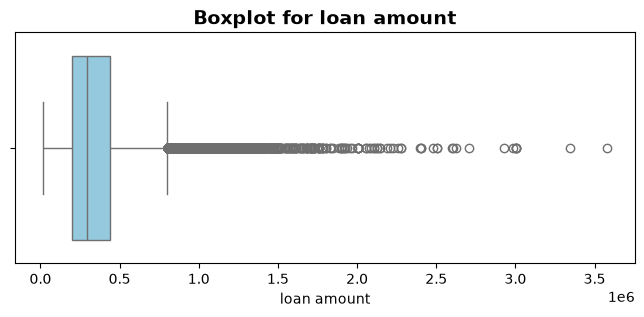

In [18]:
plt.figure(figsize=(8, 3))
# Simplified: just give it the data and a single solid color
sns.boxplot(data=df, x='loan amount', color='skyblue')
plt.title('Boxplot for loan amount', fontsize=14, fontweight='bold')
plt.xlabel('loan amount')
plt.show()

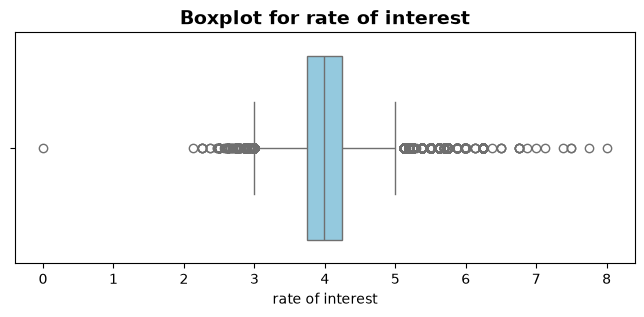

In [19]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='rate of interest', color='skyblue')
plt.title('Boxplot for rate of interest', fontsize=14, fontweight='bold')
plt.xlabel('rate of interest')
plt.show()

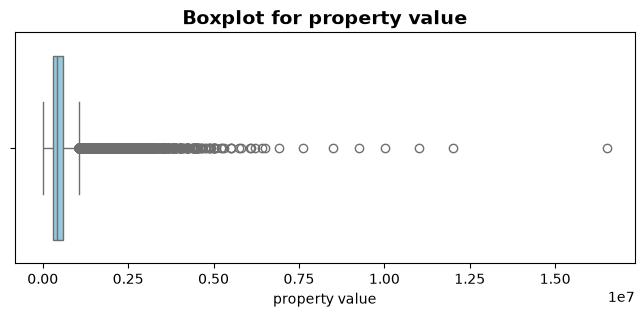

In [20]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='property value', color='skyblue')
plt.title('Boxplot for property value', fontsize=14, fontweight='bold')
plt.xlabel('property value')
plt.show()

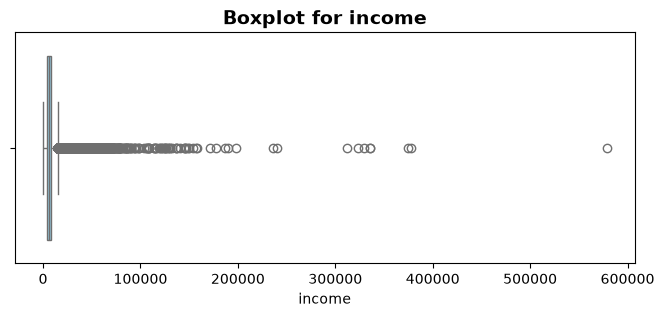

In [21]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='income', color='skyblue')
plt.title('Boxplot for income', fontsize=14, fontweight='bold')
plt.xlabel('income')
plt.show()

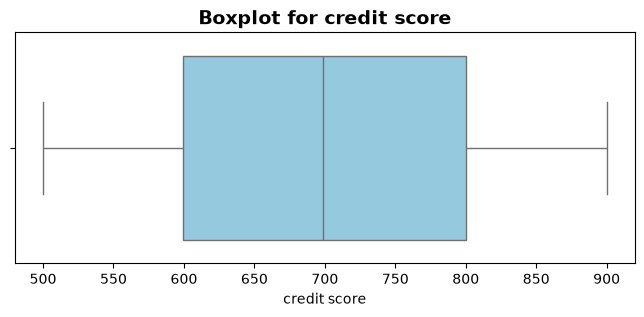

In [22]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='credit score', color='skyblue')
plt.title('Boxplot for credit score', fontsize=14, fontweight='bold')
plt.xlabel('credit score')
plt.show()

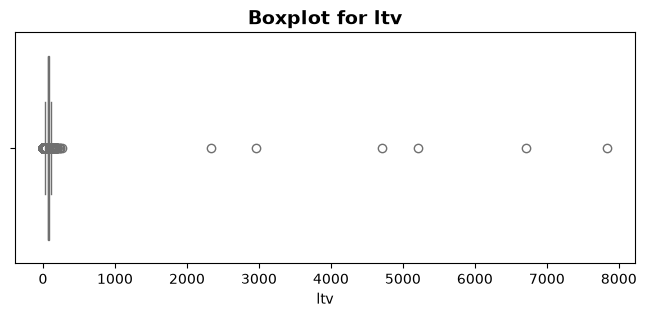

In [23]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='ltv', color='skyblue')
plt.title('Boxplot for ltv', fontsize=14, fontweight='bold')
plt.xlabel('ltv')
plt.show()

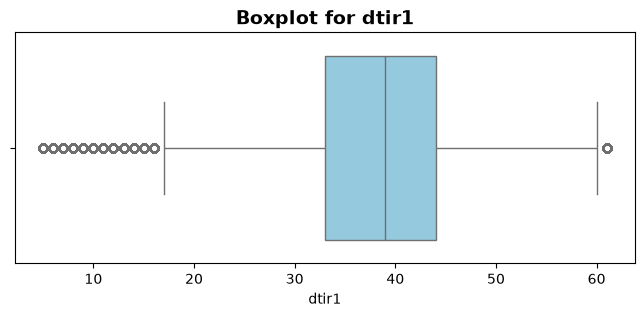

In [24]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='dtir1', color='skyblue')
plt.title('Boxplot for dtir1', fontsize=14, fontweight='bold')
plt.xlabel('dtir1')
plt.show()

In [25]:
# List of all the numerical columns with outliers
columns_to_clean = ['loan amount', 'rate of interest', 'property value', 'income', 'credit score', 'ltv', 'dtir1']

# Loop through each column and strip out its outliers directly from df
for col in columns_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter and update df in place
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Reset the index of df so it is clean and sequential
df = df.reset_index(drop=True)

# Print out a quick summary
print("=== OUTLIER REMOVAL SUMMARY ===")
print(f"Cleaned Dataset Size: {df.shape[0]} rows")

=== OUTLIER REMOVAL SUMMARY ===
Cleaned Dataset Size: 115661 rows


C:\Users\Sushil\AppData\Local\Temp\ipykernel_20880\6664469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2')


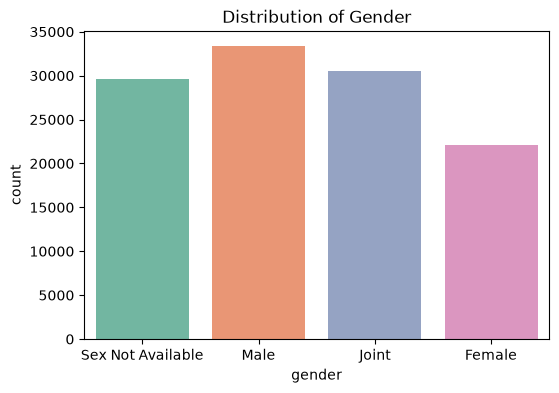

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Distribution of Gender')
plt.show()

C:\Users\Sushil\AppData\Local\Temp\ipykernel_20880\3022377416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, palette='Set2')


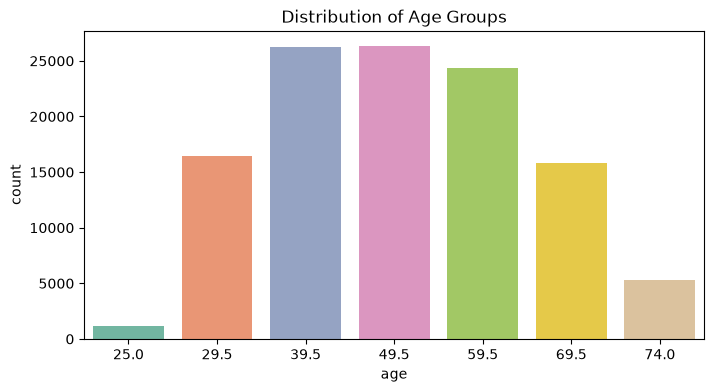

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(x='age', data=df, palette='Set2')
plt.title('Distribution of Age Groups')
plt.show()

C:\Users\Sushil\AppData\Local\Temp\ipykernel_20880\1574122460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='Set2')


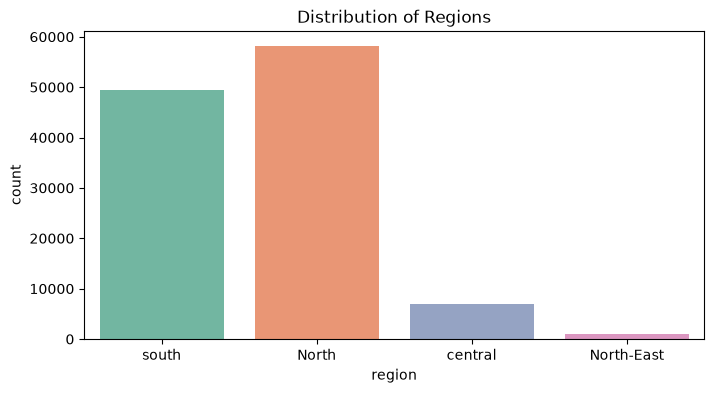

In [28]:
plt.figure(figsize=(8, 4))
sns.countplot(x='region', data=df, palette='Set2')
plt.title('Distribution of Regions')
plt.show()

C:\Users\Sushil\AppData\Local\Temp\ipykernel_20880\841954152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='Set2')


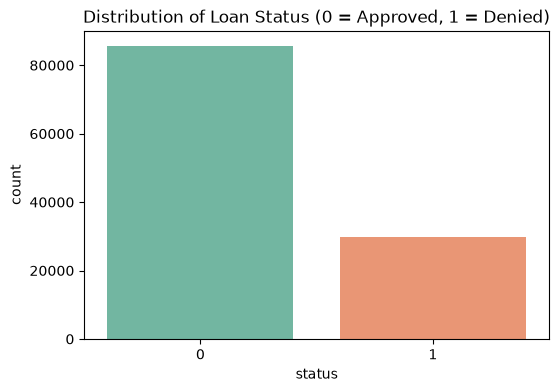

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x='status', data=df, palette='Set2')
plt.title('Distribution of Loan Status (0 = Approved, 1 = Denied)')
plt.show()

C:\Users\Sushil\AppData\Local\Temp\ipykernel_20880\2648528784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette='Set2')


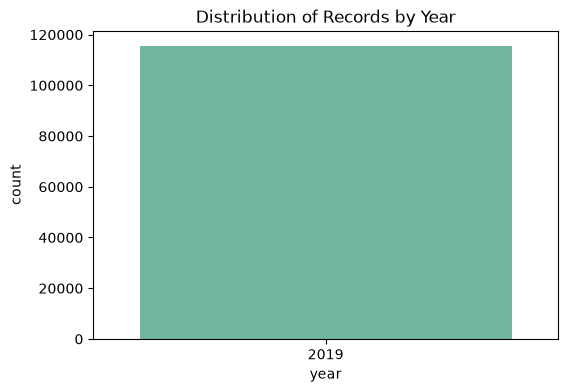

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(x='year', data=df, palette='Set2')
plt.title('Distribution of Records by Year')
plt.show()

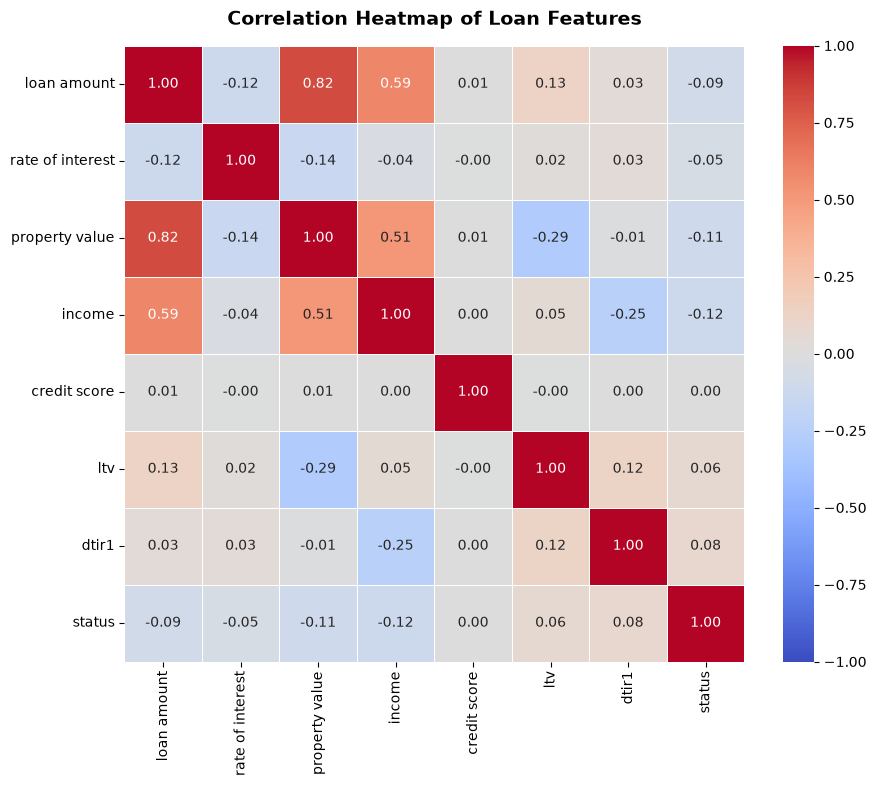

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the numerical columns (including loan status to see what correlates with approval/denial)
numerical_cols = ['loan amount', 'rate of interest', 'property value', 'income', 'credit score', 'ltv', 'dtir1', 'status']

# 2. Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# 3. Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,             # Shows the actual numbers inside each square
            cmap='coolwarm',        # Red for positive correlation, Blue for negative
            fmt=".2f",              # Rounds numbers to 2 decimal places
            linewidths=0.5,         # Adds white gridlines between squares
            vmin=-1, vmax=1)        # Sets the scale limits from -1 to 1

plt.title('Correlation Heatmap of Loan Features', fontsize=14, fontweight='bold', pad=15)
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['region'] = le.fit_transform(df['region'])
df['security type'] = le.fit_transform(df['security type'])
df

,id,year,gender,loan amount,rate of interest,property value,income,credit score,age,ltv,region,security type,status,dtir1
0,24890,2019,3,116500,3.990,118000.0,1740.0,758,29.5,98.728814,3,1,1,45.0
1,24891,2019,2,206500,3.990,418000.0,4980.0,552,59.5,75.135870,0,1,1,39.0
2,24892,2019,2,406500,4.560,508000.0,9480.0,834,39.5,80.019685,3,1,0,46.0
3,24893,2019,2,456500,4.250,658000.0,11880.0,587,49.5,69.376900,0,1,0,42.0
4,24894,2019,1,696500,4.000,758000.0,10440.0,602,29.5,91.886544,0,1,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115656,173554,2019,1,156500,3.990,158000.0,4020.0,859,69.5,99.050633,2,1,0,45.0
115657,173555,2019,3,436500,3.125,608000.0,7860.0,659,59.5,71.792763,3,1,0,48.0
115658,173557,2019,2,446500,3.125,728000.0,6900.0,702,49.5,61.332418,0,1,0,49.0
115659,173558,2019,0,196500,3.500,278000.0,7140.0,737,59.5,70.683453,0,1,0,29.0


In [33]:
# linear regression

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.03700980612529703
MAE: 0.3698568839504646
MSE: 0.1841228041855413
RMSE: 0.4290953322812325


In [34]:
# logistic regression 

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7423161717027623

Confusion Matrix:
[[17162    14]
 [ 5947    10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     17176
           1       0.42      0.00      0.00      5957

    accuracy                           0.74     23133
   macro avg       0.58      0.50      0.43     23133
weighted avg       0.66      0.74      0.63     23133



C:\Users\Sushil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
# Decision Tree Classifier

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred) * 100)

Accuracy: 91.0733584057407


In [36]:
#DECISION TREE REGRESSOR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


reg_model = DecisionTreeRegressor(max_depth=10, min_samples_split=4, min_samples_leaf=2, random_state=42)
reg_model.fit(X_train, y_train)


y_pred_reg = reg_model.predict(X_test)


print("Decision Tree Regressor Metrics:")
print("--------------------------------")
print(f"R² Score: {r2_score(y_test, y_pred_reg):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_reg):.4f}")

Decision Tree Regressor Metrics:
--------------------------------
R² Score: 0.7154
Mean Absolute Error (MAE): 0.1059
Mean Squared Error (MSE): 0.0544


In [37]:
#RANDOM FOREST CLASSIFICATION
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=10, 
                                  min_samples_split=4, min_samples_leaf=2, random_state=42)


rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)


print("Random Forest Classifier Metrics:")

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_rf) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_rf))
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf))

Random Forest Classifier Metrics:
Accuracy: 91.06%

Confusion Matrix:
[[16460   716]
 [ 1351  4606]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     17176
           1       0.87      0.77      0.82      5957

    accuracy                           0.91     23133
   macro avg       0.89      0.87      0.88     23133
weighted avg       0.91      0.91      0.91     23133



In [38]:
#RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Prepare the data
X = df.drop('status', axis=1)
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=4, 
    min_samples_leaf=2, 
    random_state=42
)

rf_regressor.fit(X_train, y_train)


y_pred_rf_reg = rf_regressor.predict(X_test)


print("Random Forest Regressor Metrics:")
print(f"R² Score: {r2_score(y_test, y_pred_rf_reg):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_rf_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_rf_reg):.4f}")

Random Forest Regressor Metrics:
R² Score: 0.7248
Mean Absolute Error (MAE): 0.1059
Mean Squared Error (MSE): 0.0526


In [39]:
#SUPPORT VECTOR CLASSIFICATION

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


df_sample = df.sample(n=10000, random_state=42)

X = df_sample.drop('status', axis=1)
y = df_sample['status']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(kernel='rbf', C=1.0, random_state=42)


svm_model.fit(X_train_scaled, Y_train)


Y_pred_svm = svm_model.predict(X_test_scaled)


print("Support Vector Classifier Metrics:")
print("---------------------------------")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_svm) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_svm))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_svm))

Support Vector Classifier Metrics:
---------------------------------
Accuracy: 85.85%

Confusion Matrix:
[[1448   43]
 [ 240  269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1491
           1       0.86      0.53      0.66       509

    accuracy                           0.86      2000
   macro avg       0.86      0.75      0.78      2000
weighted avg       0.86      0.86      0.85      2000



In [40]:
#SUPPORT VECTOR REGRESSOR

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


df_sample = df.sample(n=20000, random_state=42)

X = df_sample.drop('status', axis=1)
y = df_sample['status']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, cache_size=7000)


svr_model.fit(X_train_scaled, y_train)


y_pred_svr = svr_model.predict(X_test_scaled)


print("Support Vector Regressor Metrics:")
print(f"R² Score: {r2_score(y_test, y_pred_svr):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_svr):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_svr):.4f}")

Support Vector Regressor Metrics:
R² Score: 0.4094
Mean Absolute Error (MAE): 0.2189
Mean Squared Error (MSE): 0.1104


In [41]:
# K-NEAREST NEIGHBORS CLASSIFICATION
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split



X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_model = KNeighborsClassifier(n_neighbors=5)


knn_model.fit(X_train_scaled, Y_train)


Y_pred_knn = knn_model.predict(X_test_scaled)

print("K-Nearest Neighbors Classifier Metrics:")
print("---------------------------------------")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_knn) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_knn))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_knn))

K-Nearest Neighbors Classifier Metrics:
---------------------------------------
Accuracy: 85.30%

Confusion Matrix:
[[15692  1484]
 [ 1917  4040]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     17176
           1       0.73      0.68      0.70      5957

    accuracy                           0.85     23133
   macro avg       0.81      0.80      0.80     23133
weighted avg       0.85      0.85      0.85     23133



In [42]:
# K-NEAREST NEIGHBORS REGRESSOR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split




X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_regressor = KNeighborsRegressor(n_neighbors=5)


knn_regressor.fit(X_train_scaled, y_train)


y_pred_knn_reg = knn_regressor.predict(X_test_scaled)


print("K-Nearest Neighbors Regressor Metrics:")
print("-------------------------------------")
print(f"R² Score: {r2_score(y_test, y_pred_knn_reg):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_knn_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_knn_reg):.4f}")

K-Nearest Neighbors Regressor Metrics:
-------------------------------------
R² Score: 0.4525
Mean Absolute Error (MAE): 0.1828
Mean Squared Error (MSE): 0.1047


In [43]:

# ARTIFICIAL NEURAL NETWORK (ANN) REGRESSOR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)
ann_regressor.fit(X_train_scaled, y_train)


y_pred_ann_reg = ann_regressor.predict(X_test_scaled)

print("ANN Regressor Metrics:")
print("----------------------")
print(f"R² Score: {r2_score(y_test, y_pred_ann_reg):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_ann_reg):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_ann_reg):.4f}")

ANN Regressor Metrics:
----------------------
R² Score: 0.7078
Mean Absolute Error (MAE): 0.1236
Mean Squared Error (MSE): 0.0559


In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import joblib

# 1. Select ONLY the 7 exact columns
selected_columns = ['gender', 'loan amount', 'rate of interest', 'property value', 'income', 'credit score', 'age']
X_lean = df[selected_columns]
y = df['status']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.2, random_state=42)

# 3. Create a BRAND NEW scaler specifically for these 7 columns
lean_scaler = StandardScaler()
X_train_scaled = lean_scaler.fit_transform(X_train)

# 4. Train a BRAND NEW ANN model
print("Training the 7-feature model...")
ann_classifier_lean = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann_classifier_lean.fit(X_train_scaled, y_train)

# 5. Save the correct 7-feature model and scaler (This will overwrite the broken ones!)
joblib.dump(ann_classifier_lean, 'ann_loan_model_lean.pkl')
joblib.dump(lean_scaler, 'loan_scaler_lean.pkl')

print("✅ SUCCESS: The true 7-feature model and scaler have been saved!")

Training the 7-feature model...
✅ SUCCESS: The true 7-feature model and scaler have been saved!


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Scale the test data using the NEW lean scaler (This was the missing piece!)
X_test_scaled = lean_scaler.transform(X_test)

# 2. Make predictions on your test data
y_pred_lean = ann_classifier_lean.predict(X_test_scaled)

# 3. Print out the accuracy and metrics
print("7-Feature ANN Classifier Metrics:")
print("---------------------------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lean) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lean))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lean))

7-Feature ANN Classifier Metrics:
---------------------------------
Accuracy: 90.18%

Confusion Matrix:
[[15923  1253]
 [ 1018  4939]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     17176
           1       0.80      0.83      0.81      5957

    accuracy                           0.90     23133
   macro avg       0.87      0.88      0.87     23133
weighted avg       0.90      0.90      0.90     23133

